# WEC Power Estimation: Leixões Sea-State Characterization and Generic Power Matrix

This notebook uses the processed Leixões buoy sea-state table prepared in [Notebook 01](01_wave_data_preparation.ipynb).

The goal is to explore the available wave-height, period, direction, and extreme-wave variables before converting the sea-state record into a simplified estimated WEC electrical power signal.

The notebook is organized in three phases:

1. **Site characterization** — visualize the observed wave conditions and directionality.
2. **Sea-state consistency and operating-condition checks** — compare related height and period variables and define simple flags for interpretation.
3. **Simplified WEC electrical power estimation** — use a generic power-matrix-style approach to estimate an illustrative WEC power-output signal.

The estimated WEC power signal is intended for later forecasting, uncertainty, and storage-smoothing examples. It is not a validated device model or detailed WEC hydrodynamic simulation.


## Phase 1 — Site characterization

This phase gives a first visual overview of the Leixões buoy sea-state record prepared in [Notebook 01](01_wave_data_preparation.ipynb).

We start with the two main variables that will later drive the simplified WEC power estimate:

- `hm0_m`: spectral significant wave height
- `tp_s`: peak wave period

Missing values are kept as gaps in the plots.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mhkit.wave import graphics as wave_graphics

# Paths
PROCESSED_DATA_PATH = Path("../data/processed/leixoes_wave_30min_processed.parquet")
FIGURE_DIR = Path("../outputs/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load processed sea-state table from Notebook 01
wave_df = pd.read_parquet(PROCESSED_DATA_PATH)

wave_df["time"] = pd.to_datetime(wave_df["time"])
wave_df = wave_df.sort_values("time").reset_index(drop=True)

### Time series overview of wave height and peak period

This plot shows how significant wave height and peak period vary through the available February–June 2025 record.

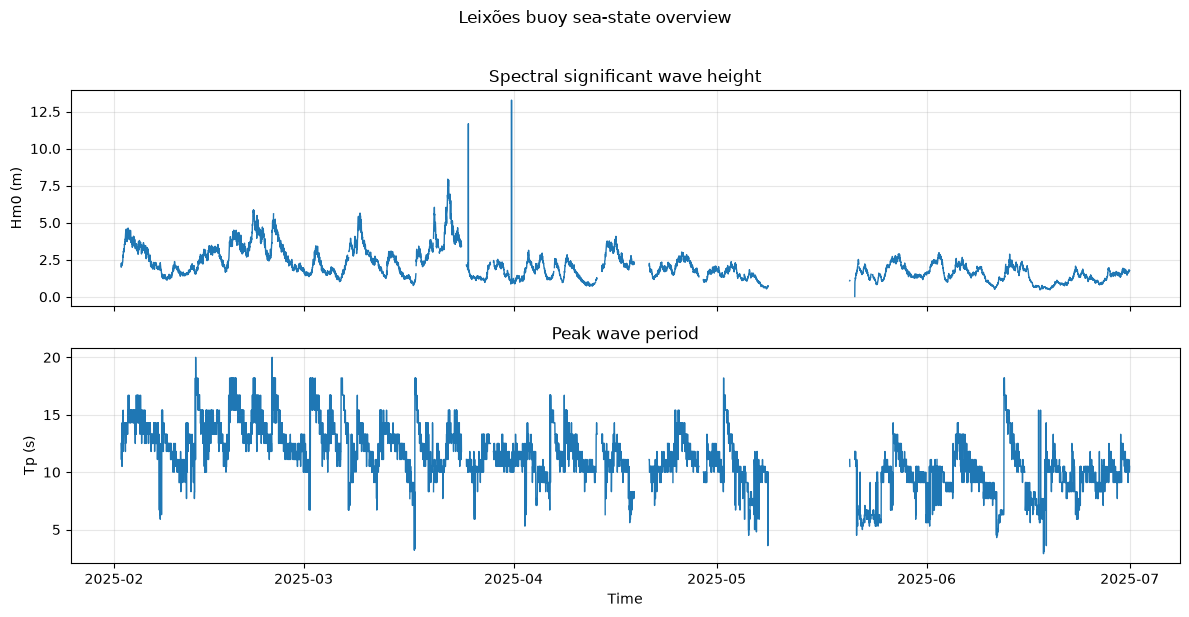

In [3]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 6),
    sharex=True,
)

axes[0].plot(wave_df["time"], wave_df["hm0_m"], linewidth=1.0)
axes[0].set_ylabel("Hm0 (m)")
axes[0].set_title("Spectral significant wave height")

axes[1].plot(wave_df["time"], wave_df["tp_s"], linewidth=1.0)
axes[1].set_ylabel("Tp (s)")
axes[1].set_xlabel("Time")
axes[1].set_title("Peak wave period")

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.suptitle("Leixões buoy sea-state overview", y=1.02)
fig.tight_layout()

plt.show()

### Sea-state cloud: wave height versus peak period

The simplified WEC power estimate will mainly depend on wave height and wave period.  
This scatter plot shows the observed `hm0_m`–`tp_s` combinations in the Leixões record.

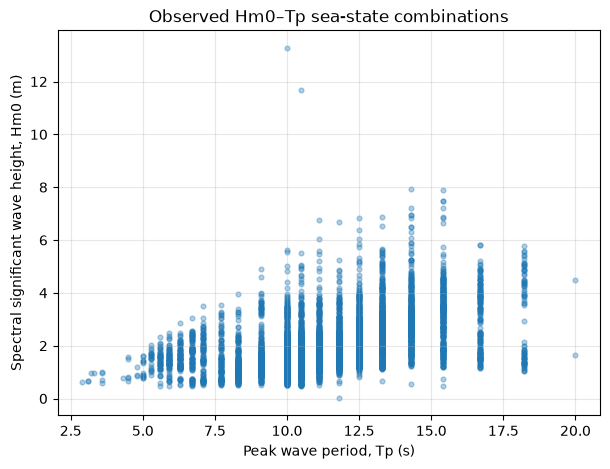

In [5]:
sea_state_df = wave_df.dropna(subset=["hm0_m", "tp_s"]).copy()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    sea_state_df["tp_s"],
    sea_state_df["hm0_m"],
    s=12,
    alpha=0.35,
)

ax.set_xlabel("Peak wave period, Tp (s)")
ax.set_ylabel("Spectral significant wave height, Hm0 (m)")
ax.set_title("Observed Hm0–Tp sea-state combinations")
ax.grid(True, alpha=0.3)

plt.show()

Most observed sea states are concentrated between about 5–17 s peak period and below roughly 5 m significant wave height. A few much larger wave-height values appear as energetic events or possible extremes in the record.